# 📊 Advanced Mutual Fund Analytics — Day 6
## Risk Analytics, Investor Behaviour & Fund Intelligence

**Objective:** Build production-grade analytics covering risk metrics (VaR/CVaR), 
rolling performance, investor segmentation, SIP health, and portfolio concentration.

| Module | Description |
|--------|-------------|
| Task 1 | Historical VaR (95%) & CVaR for all 40 schemes |
| Task 2 | Rolling 90-day Sharpe Ratio — 5 key funds |
| Task 3 | Investor cohort analysis by first transaction year |
| Task 4 | SIP continuity analysis & at-risk flagging |
| Task 5 | Risk-based fund recommender |
| Task 6 | Sector HHI concentration across equity funds |
| Task 7 | 5 Advanced Insights |

In [1]:
# ── 0. Imports & Configuration ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Plot aesthetics
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 10,
})
PALETTE = ['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED','#0891B2','#BE185D']

# ── DATA PATH ─────────────────────────────────────────────────────────────────
DATA = r'G:\bluestock_mf_capstone\data\processed' + os.sep

print("✅  Libraries loaded")
print(f"📂  Data folder: {DATA}")

✅  Libraries loaded
📂  Data folder: G:\bluestock_mf_capstone\data\processed\


In [2]:
# ── 0b. Load all datasets ──────────────────────────────────────────────────────
def find_file(data_dir, *candidates):
    """Try multiple filename candidates; return first one that exists."""
    for name in candidates:
        path = os.path.join(data_dir, name)
        if os.path.exists(path):
            return path
    # Fuzzy fallback: match by suffix after first underscore block
    for f in sorted(os.listdir(data_dir)):
        for c in candidates:
            if f.endswith(c):
                return os.path.join(data_dir, f)
    raise FileNotFoundError(
        f"Cannot find any of {candidates}\n"
        f"in: {data_dir}\n"
        "👉 Make sure all your CSV files are in the same folder as this notebook."
    )

nav   = pd.read_csv(find_file(DATA, 'nav_clean.csv',          '1781538436533_nav_clean.csv'),          parse_dates=['date'])
perf  = pd.read_csv(find_file(DATA, 'performance_clean.csv',  '1781538436533_performance_clean.csv'))
fund  = pd.read_csv(find_file(DATA, 'fund_clean.csv',         '1781538436532_fund_clean.csv'))
tx    = pd.read_csv(find_file(DATA, 'transactions_clean.csv', '1781538436534_transactions_clean.csv'), parse_dates=['transaction_date'])
hold  = pd.read_csv(find_file(DATA, 'holdings_clean.csv',     '1781538436532_holdings_clean.csv'))
score = pd.read_csv(find_file(DATA, 'fund_scorecard.csv',     '1781538436532_fund_scorecard.csv'))
ab    = pd.read_csv(find_file(DATA, 'alpha_beta.csv',         '1781538436529_alpha_beta.csv'))

print(f"NAV records    : {len(nav):,}  ({nav['amfi_code'].nunique()} schemes)")
print(f"Performance    : {len(perf):,}  funds")
print(f"Transactions   : {len(tx):,}  records")
print(f"Holdings       : {len(hold):,}  rows")
print(f"Date range     : {nav['date'].min().date()} → {nav['date'].max().date()}")
print("✅  All datasets loaded successfully!")

NAV records    : 46,000  (40 schemes)
Performance    : 40  funds
Transactions   : 32,778  records
Holdings       : 322  rows
Date range     : 2022-01-03 → 2026-05-29
✅  All datasets loaded successfully!


Historical VaR (95%) & CVaR for All 40 Schemes

Saved var_cvar_report.csv — 40 schemes


,scheme_name,VaR_95_pct,CVaR_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,-2.6859,-3.2384
17,Axis Small Cap Fund - Regular - Growth,-2.6188,-3.1667
4,ABSL Small Cap Fund - Regular - Growth,-2.6021,-3.2459
11,Nippon India Small Cap Fund - Regular - Growth,-2.5438,-3.2304
21,SBI Small Cap Fund - Regular Plan - Growth,-2.4507,-3.0595
39,DSP Small Cap Fund - Regular - Growth,-2.3483,-3.1036
7,UTI Mid Cap Fund - Regular - Growth,-1.9220,-2.3251
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.9034,-2.3456
25,ICICI Pru Midcap Fund - Regular - Growth,-1.8892,-2.4342
16,Axis Midcap Fund - Regular - Growth,-1.8480,-2.4260


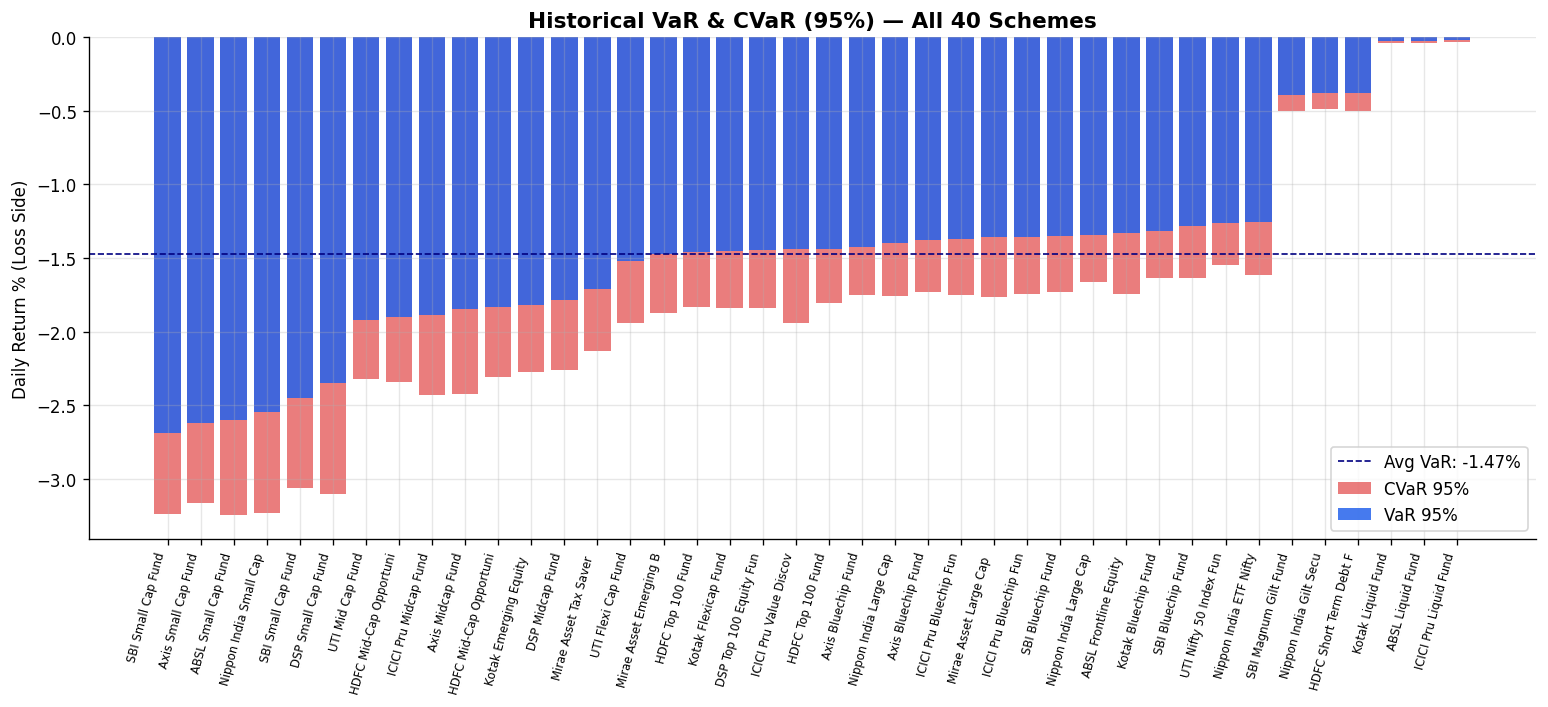


Riskiest fund : SBI Small Cap Fund - Direct Plan - Growth
Safest fund   : ICICI Pru Liquid Fund - Regular - Growth


In [3]:
# ── TASK 1: Historical VaR (95%) & CVaR — Compute + Visualise ────────────────

# Step 1: Daily returns
nav_sorted = nav.sort_values(['amfi_code','date'])
nav_sorted['daily_return'] = nav_sorted.groupby('amfi_code')['nav'].pct_change()

# Step 2: VaR (5th percentile) and CVaR (mean of tail)
var_rows = []
for code, grp in nav_sorted.groupby('amfi_code'):
    r = grp['daily_return'].dropna()
    if len(r) < 30: continue
    var_95  = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    sname   = perf.loc[perf['amfi_code']==code,'scheme_name'].values
    var_rows.append({
        'amfi_code'   : code,
        'scheme_name' : sname[0] if len(sname) else str(code),
        'VaR_95_pct'  : round(var_95*100, 4),
        'CVaR_95_pct' : round(cvar_95*100, 4),
        'n_days'      : len(r)
    })

var_df = pd.DataFrame(var_rows).sort_values('VaR_95_pct')
var_df.to_csv(os.path.join(DATA, 'var_cvar_report.csv'), index=False)
print(f"Saved var_cvar_report.csv — {len(var_df)} schemes")
display(var_df[['scheme_name','VaR_95_pct','CVaR_95_pct']].head(10))

# Step 3: Visualise
fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(var_df))
ax.bar(x, var_df['CVaR_95_pct'], color='#DC2626', alpha=0.6, label='CVaR 95%', width=0.8)
ax.bar(x, var_df['VaR_95_pct'],  color='#2563EB', alpha=0.85, label='VaR 95%',  width=0.8)
labels = [s.split(' - ')[0][:22] for s in var_df['scheme_name']]
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=75, ha='right', fontsize=7)
ax.set_title('Historical VaR & CVaR (95%) — All 40 Schemes', fontsize=13, fontweight='bold')
ax.set_ylabel('Daily Return % (Loss Side)')
ax.axhline(var_df['VaR_95_pct'].mean(), color='navy', linestyle='--', linewidth=1,
           label=f"Avg VaR: {var_df['VaR_95_pct'].mean():.2f}%")
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nRiskiest fund : {var_df.iloc[0]['scheme_name'][:55]}")
print(f"Safest fund   : {var_df.iloc[-1]['scheme_name'][:55]}")

Rolling 90-Day Sharpe Ratio (5 Key Funds)

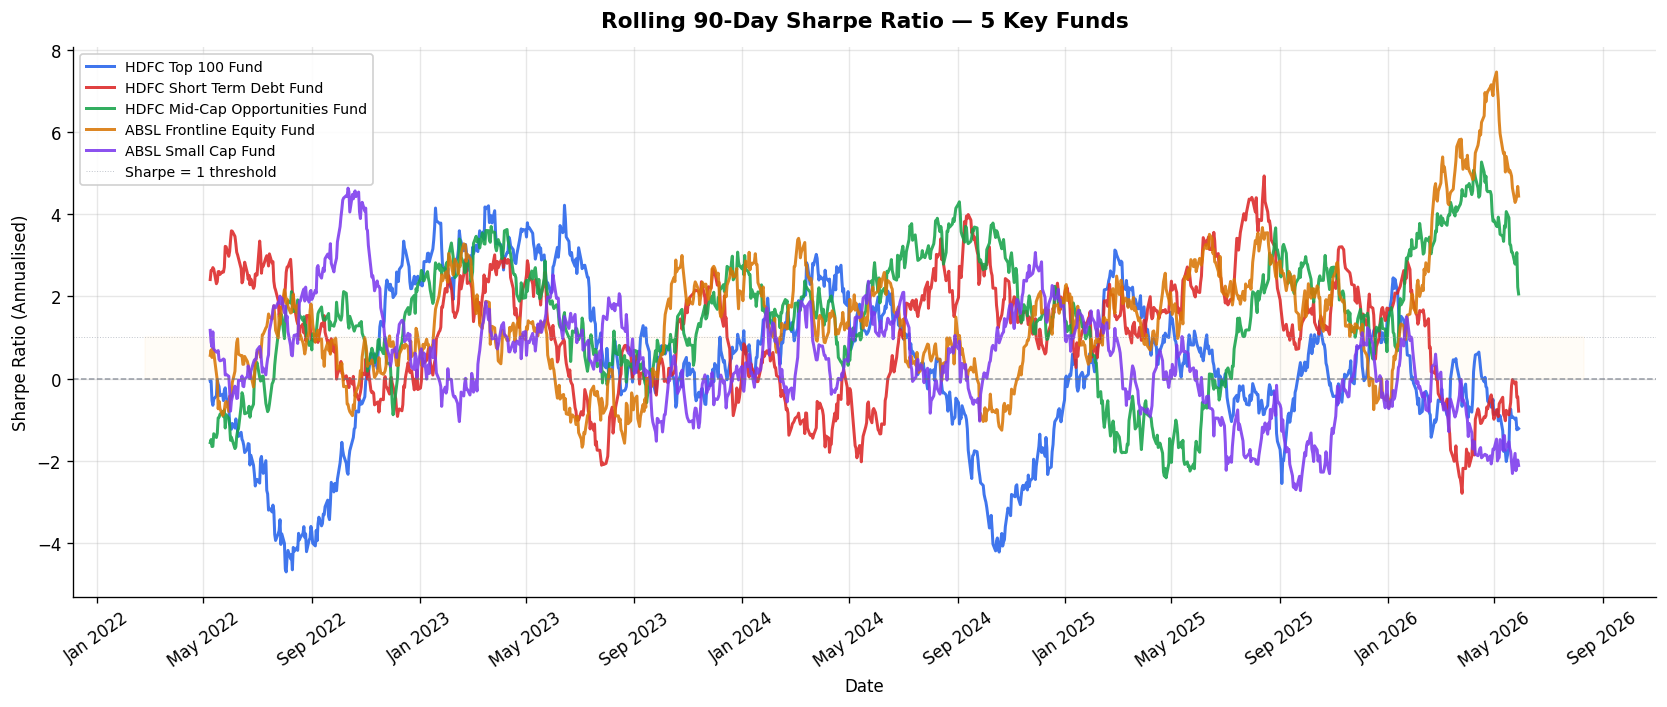

✅  Chart saved to: G:\bluestock_mf_capstone\reports\rolling_sharpe_chart.png


In [4]:
# ── TASK 2: Rolling 90-Day Sharpe Ratio (5 Key Funds) ────────────────────────

# Select 5 funds with most complete NAV data
top5_codes = (nav_sorted.groupby('amfi_code')['date']
              .count().nlargest(5).index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
for i, code in enumerate(top5_codes):
    grp = nav_sorted[nav_sorted['amfi_code']==code].set_index('date')
    r   = grp['daily_return']
    # Rolling Sharpe = annualised mean / std over 90-day window
    roll_sharpe = (r.rolling(90).mean() / r.rolling(90).std()) * np.sqrt(252)
    sname = perf.loc[perf['amfi_code']==code,'scheme_name'].values
    label = (sname[0].split(' - ')[0] if len(sname) else str(code))[:35]
    ax.plot(roll_sharpe.index, roll_sharpe, color=PALETTE[i],
            linewidth=1.8, label=label, alpha=0.88)

ax.axhline(0, color='#6B7280', linewidth=0.9, linestyle='--', alpha=0.7)
ax.axhline(1, color='#9CA3AF', linewidth=0.6, linestyle=':', alpha=0.6, label='Sharpe = 1 threshold')
ax.fill_between(ax.get_xlim(), 0, 1, alpha=0.03, color='orange')
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Sharpe Ratio (Annualised)')
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=35)
plt.tight_layout()

# Save chart to reports folder
REPORTS = r'G:\bluestock_mf_capstone\reports'
os.makedirs(REPORTS, exist_ok=True)
chart_path = os.path.join(REPORTS, 'rolling_sharpe_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅  Chart saved to: {chart_path}")

Investor Cohort Analysis

Investor Cohort Analysis:


,investor_count,avg_sip_amount,total_invested,top_fund_name
first_year,,,,
2024,4456,10986.86,212189262,HDFC Mid-Cap Opportunities Fund - Direct - Growth
2025,306,12516.70,5044229,SBI Small Cap Fund - Direct Plan - Growth


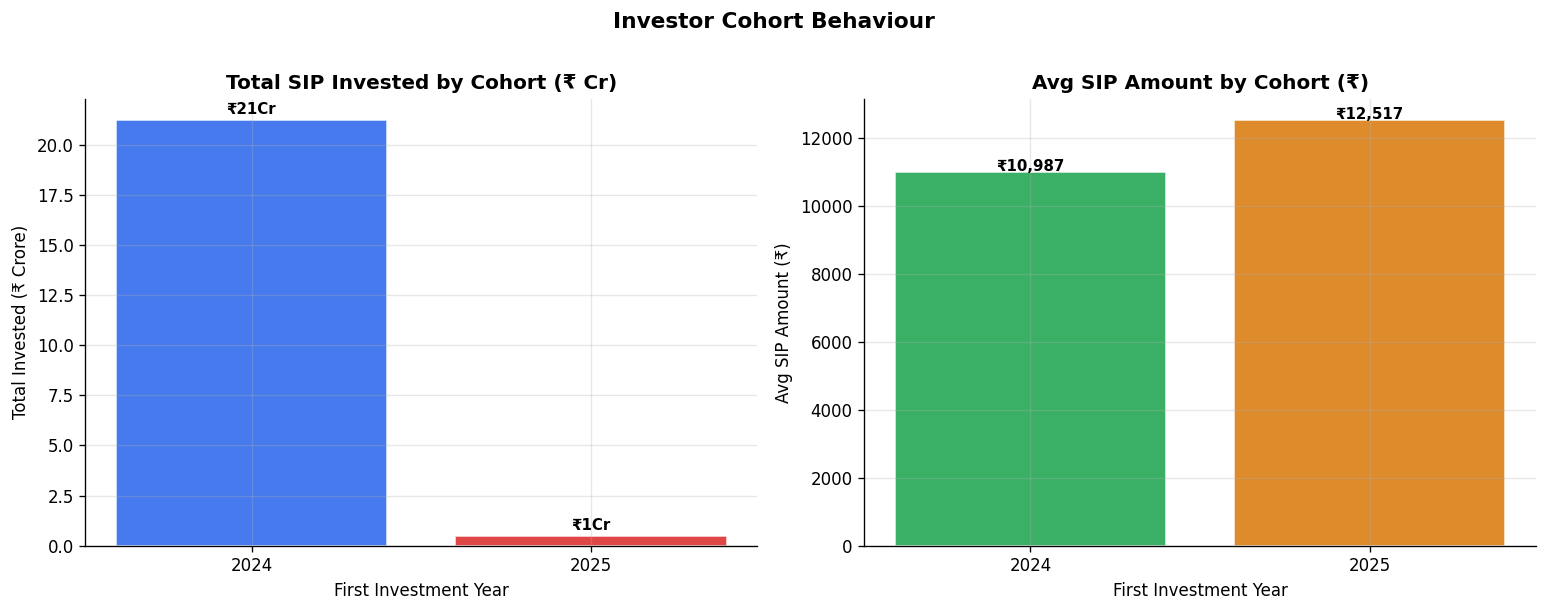

In [5]:
# ── TASK 3: Investor Cohort Analysis — Compute + Visualise ───────────────────

sip_tx = tx[tx['transaction_type']=='SIP'].copy()
sip_tx['first_year'] = (sip_tx
    .groupby('investor_id')['transaction_date']
    .transform('min').dt.year)

cohort = sip_tx.groupby('first_year').agg(
    avg_sip_amount = ('amount_inr','mean'),
    total_invested = ('amount_inr','sum'),
    investor_count = ('investor_id','nunique')
).round(2)

# Top fund per cohort — compatible with all pandas versions
def top_fund(df):
    return df.groupby('amfi_code')['amount_inr'].sum().idxmax()

top_funds = (sip_tx.groupby('first_year', group_keys=False)
             .apply(top_fund)
             .reset_index())
top_funds.columns = ['first_year', 'top_amfi_code']
top_funds = top_funds.set_index('first_year')['top_amfi_code']

cohort = cohort.join(top_funds)
cohort = cohort.reset_index().merge(
    perf[['amfi_code','scheme_name']].rename(
        columns={'amfi_code':'top_amfi_code','scheme_name':'top_fund_name'}),
    on='top_amfi_code', how='left'
).set_index('first_year')

print("Investor Cohort Analysis:")
display(cohort[['investor_count','avg_sip_amount','total_invested','top_fund_name']])

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cohort_r = cohort.reset_index()

axes[0].bar(cohort_r['first_year'].astype(str), cohort_r['total_invested']/1e7,
            color=PALETTE[:len(cohort_r)], alpha=0.85, edgecolor='white')
axes[0].set_title('Total SIP Invested by Cohort (₹ Cr)', fontweight='bold')
axes[0].set_xlabel('First Investment Year')
axes[0].set_ylabel('Total Invested (₹ Crore)')
for bar, val in zip(axes[0].patches, cohort_r['total_invested']/1e7):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'₹{val:.0f}Cr', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(cohort_r['first_year'].astype(str), cohort_r['avg_sip_amount'],
            color=PALETTE[2:2+len(cohort_r)], alpha=0.85, edgecolor='white')
axes[1].set_title('Avg SIP Amount by Cohort (₹)', fontweight='bold')
axes[1].set_xlabel('First Investment Year')
axes[1].set_ylabel('Avg SIP Amount (₹)')
for bar, val in zip(axes[1].patches, cohort_r['avg_sip_amount']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'₹{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Investor Cohort Behaviour', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

SIP Continuity Analysis & At-Risk Flagging

Investors with 6+ SIPs   : 1,362
Healthy (gap ≤ 35 days)  : 30 (2.2%)
At-Risk (gap > 35 days)  : 1,332 (97.8%)

Avg gap — overall        : 64.9 days
Avg gap — healthy         : 30.3 days
Avg gap — at-risk         : 65.7 days


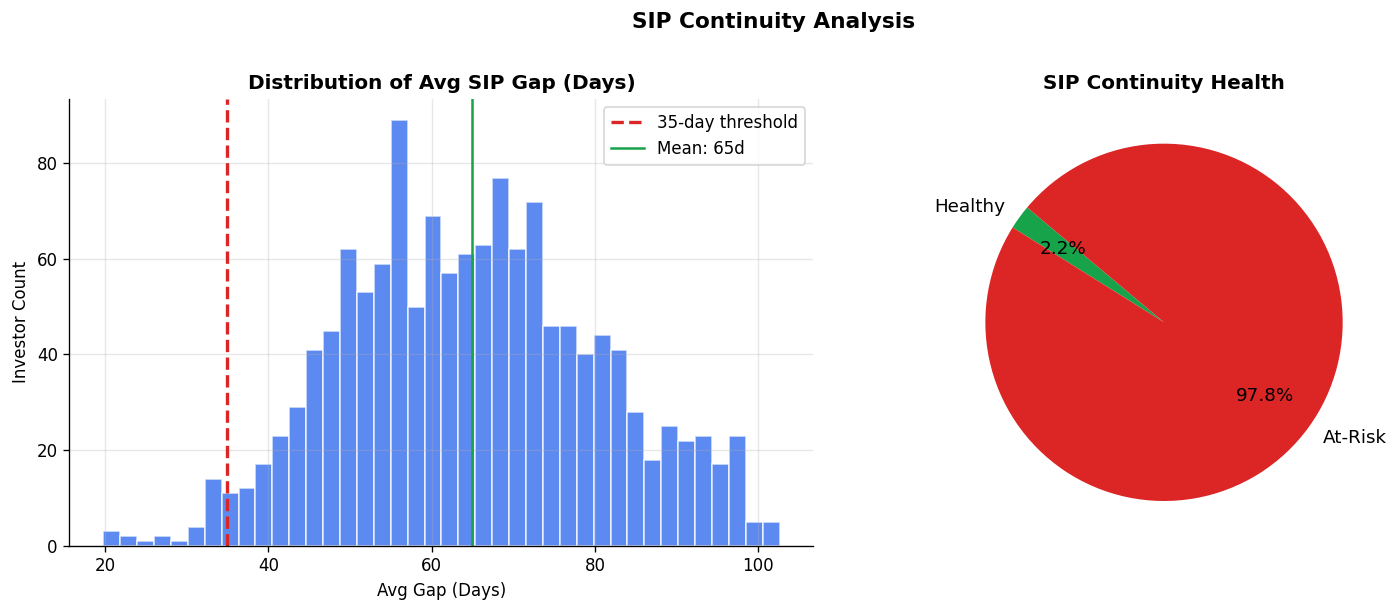

In [6]:
# ── TASK 4: SIP Continuity Analysis & At-Risk Flagging ────────────────────────

sip_sorted = sip_tx.sort_values(['investor_id','transaction_date'])

eligible = (sip_sorted.groupby('investor_id')
            .filter(lambda x: len(x) >= 6))

avg_gap = (eligible.groupby('investor_id')['transaction_date']
           .apply(lambda d: d.diff().dt.days.dropna().mean()))

sip_cont = avg_gap.reset_index()
sip_cont.columns = ['investor_id','avg_gap_days']
sip_cont['at_risk']    = sip_cont['avg_gap_days'] > 35
sip_cont['risk_label'] = sip_cont['at_risk'].map({True:'At-Risk 🔴', False:'Healthy 🟢'})

total            = len(sip_cont)
at_risk_n        = sip_cont['at_risk'].sum()
healthy_n        = total - at_risk_n
continuity_rate  = round(healthy_n / total * 100, 1)

print(f"Investors with 6+ SIPs   : {total:,}")
print(f"Healthy (gap ≤ 35 days)  : {healthy_n:,} ({continuity_rate}%)")
print(f"At-Risk (gap > 35 days)  : {at_risk_n:,} ({100-continuity_rate:.1f}%)")
print(f"\nAvg gap — overall        : {sip_cont['avg_gap_days'].mean():.1f} days")
print(f"Avg gap — healthy         : {sip_cont[~sip_cont['at_risk']]['avg_gap_days'].mean():.1f} days")
print(f"Avg gap — at-risk         : {sip_cont[sip_cont['at_risk']]['avg_gap_days'].mean():.1f} days")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(sip_cont['avg_gap_days'], bins=40, color='#2563EB', alpha=0.75, edgecolor='white')
axes[0].axvline(35, color='#DC2626', linewidth=2, linestyle='--', label='35-day threshold')
axes[0].axvline(sip_cont['avg_gap_days'].mean(), color='#16A34A', linewidth=1.5,
                linestyle='-', label=f"Mean: {sip_cont['avg_gap_days'].mean():.0f}d")
axes[0].set_title('Distribution of Avg SIP Gap (Days)', fontweight='bold')
axes[0].set_xlabel('Avg Gap (Days)'); axes[0].set_ylabel('Investor Count')
axes[0].legend()

axes[1].pie([healthy_n, at_risk_n], labels=['Healthy', 'At-Risk'],
            colors=['#16A34A','#DC2626'], autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':11}, pctdistance=0.7)
axes[1].set_title('SIP Continuity Health', fontweight='bold')
plt.suptitle('SIP Continuity Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Risk-Based Fund Recommender


  🎯  Risk Appetite: LOW
                                scheme_name risk_grade  sharpe_ratio  return_1yr_pct  return_3yr_pct  expense_ratio_pct  max_drawdown_pct
1  ICICI Pru Liquid Fund - Regular - Growth        Low          7.68            8.89            7.68               0.74             -2.62
2      Kotak Liquid Fund - Regular - Growth        Low          6.18            4.26            6.18               0.60             -3.81
3       ABSL Liquid Fund - Regular - Growth        Low          5.14            6.18            5.14               0.79             -3.66

  🎯  Risk Appetite: MODERATE
                                     scheme_name risk_grade  sharpe_ratio  return_1yr_pct  return_3yr_pct  expense_ratio_pct  max_drawdown_pct
1      HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06           10.94           14.84               1.55            -17.41
2  Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06           15.12           14.81  

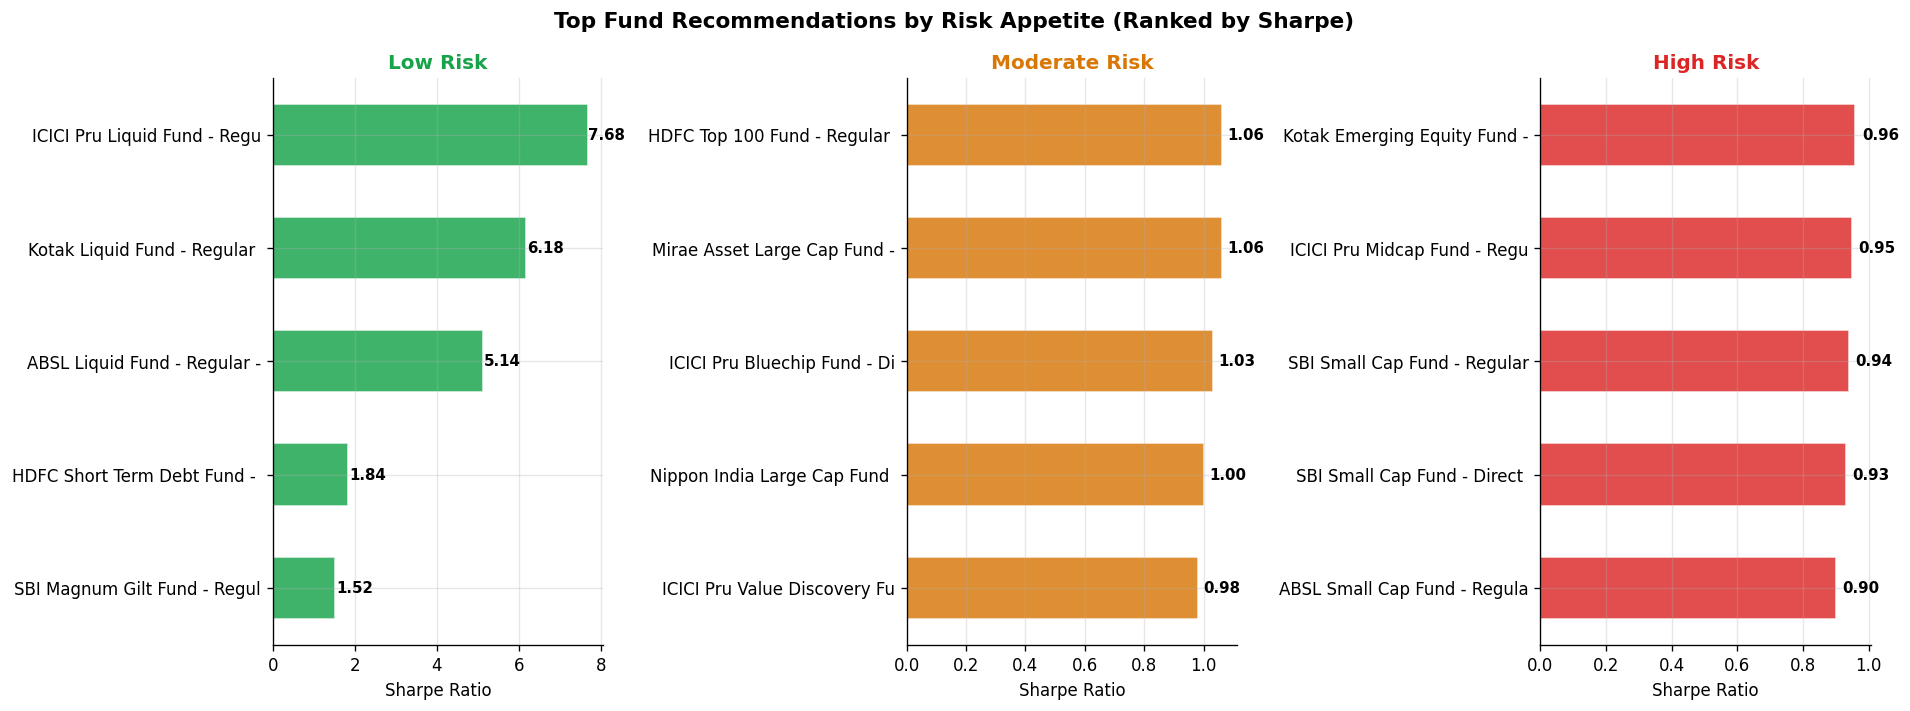

In [7]:
# ── TASK 5: Risk-Based Fund Recommender ──────────────────────────────────────

RISK_MAP = {
    'Low'      : ['Low'],
    'Moderate' : ['Moderate','Moderately High'],
    'High'     : ['High','Very High'],
}

def recommend_funds(risk_appetite: str, n: int = 3) -> pd.DataFrame:
    """Return top-n funds by Sharpe ratio for the given risk appetite."""
    grades = RISK_MAP.get(risk_appetite, ['Moderate'])
    subset = perf[perf['risk_grade'].isin(grades)].copy()
    top = (subset
           .nlargest(n, 'sharpe_ratio')
           [['scheme_name','risk_grade','sharpe_ratio','return_1yr_pct',
             'return_3yr_pct','expense_ratio_pct','max_drawdown_pct']]
           .reset_index(drop=True))
    top.index += 1
    return top

for appetite in ['Low','Moderate','High']:
    print(f"\n{'='*70}")
    print(f"  🎯  Risk Appetite: {appetite.upper()}")
    print(f"{'='*70}")
    df_rec = recommend_funds(appetite)
    df_rec['scheme_name'] = df_rec['scheme_name'].str[:45]
    print(df_rec.to_string())

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
for ax, (appetite, color) in zip(axes, [('Low','#16A34A'),('Moderate','#D97706'),('High','#DC2626')]):
    df_r = recommend_funds(appetite, 5)
    names = [n[:28] for n in df_r['scheme_name']]
    bars = ax.barh(names, df_r['sharpe_ratio'], color=color, alpha=0.82, edgecolor='white', height=0.55)
    ax.set_title(f'{appetite} Risk', fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel('Sharpe Ratio')
    ax.invert_yaxis()
    for bar, val in zip(bars, df_r['sharpe_ratio']):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
plt.suptitle('Top Fund Recommendations by Risk Appetite (Ranked by Sharpe)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Sector HHI Concentration (Equity Funds)

Sector HHI Concentration — Equity Funds:
  HHI > 0.25 = Highly Concentrated | 0.15–0.25 = Moderate | <0.15 = Diversified



,amfi_code,scheme_name,HHI,top_sector,top_weight%,n_sectors
11,119092,Axis Bluechip Fund,0.2968,IT,48.7,7
30,148569,Mirae Asset Tax Saver Fund,0.2550,Banking,39.8,7
27,125498,HDFC Mid-Cap Opportunities Fund,0.2532,Banking,41.2,6
6,102887,UTI Flexi Cap Fund,0.2514,Pharma,39.0,6
32,149323,DSP Midcap Fund,0.2411,Pharma,41.3,7
21,120505,ICICI Pru Midcap Fund,0.2387,Pharma,40.8,7
10,118635,Nippon India ETF Nifty 50 BeES,0.2375,IT,39.3,6
18,119599,SBI Small Cap Fund,0.2324,Banking,34.1,7
22,120506,ICICI Pru Value Discovery Fund,0.2315,Banking,30.4,7
1,100033,HDFC Mid-Cap Opportunities Fund,0.2276,Banking,36.0,7


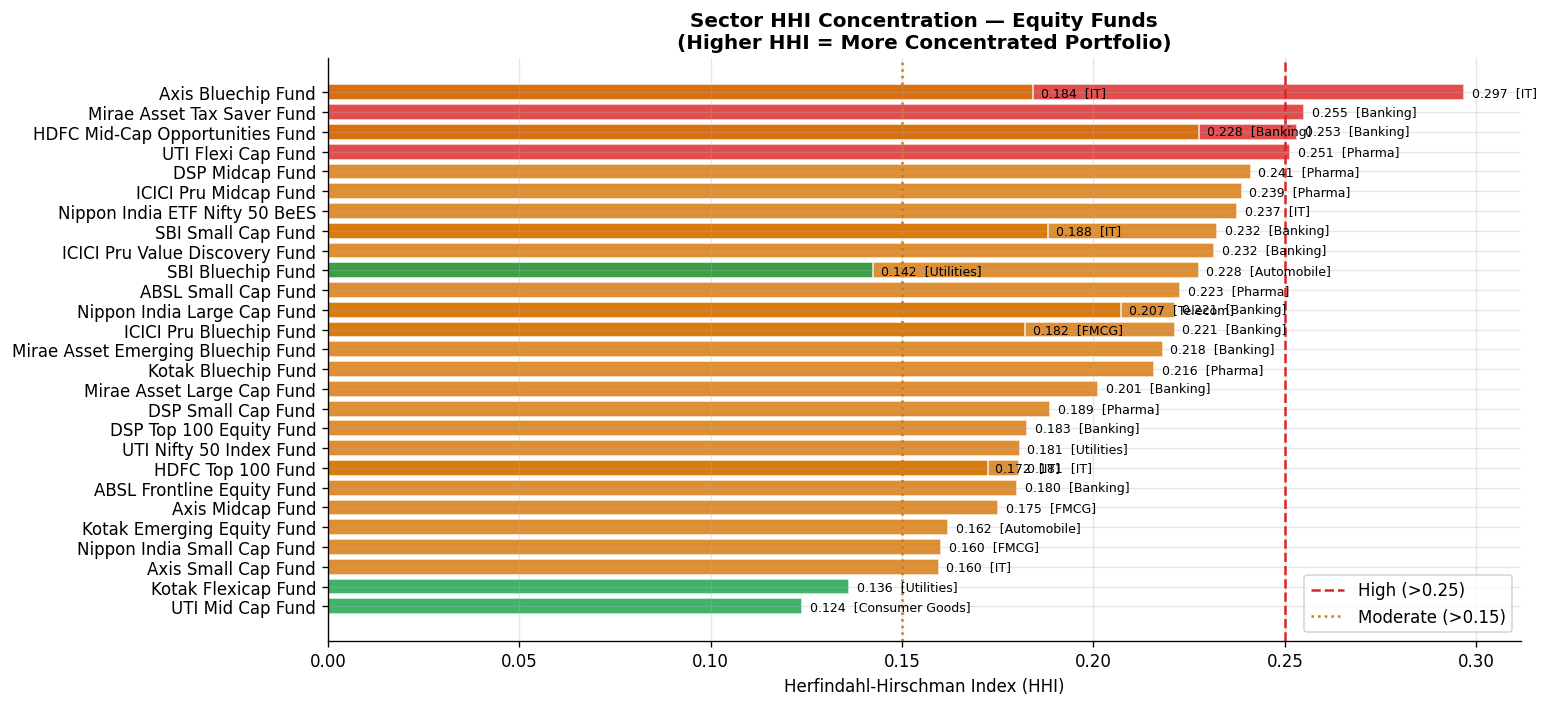

In [8]:
# ── TASK 6: Sector HHI Concentration (Equity Funds) ──────────────────────────

equity_funds = fund[fund['category']=='Equity']['amfi_code'].tolist()
eq_hold      = hold[hold['amfi_code'].isin(equity_funds)].copy()
eq_hold['weight_frac'] = eq_hold['weight_pct'] / 100

hhi_rows = []
for code, grp in eq_hold.groupby('amfi_code'):
    sector_w = grp.groupby('sector')['weight_frac'].sum()
    hhi = (sector_w**2).sum()
    sname = fund.loc[fund['amfi_code']==code,'scheme_name'].values
    hhi_rows.append({
        'amfi_code'  : code,
        'scheme_name': (sname[0].split(' - ')[0] if len(sname) else str(code))[:35],
        'HHI'        : round(hhi, 4),
        'top_sector' : sector_w.idxmax(),
        'top_weight%': round(sector_w.max()*100, 1),
        'n_sectors'  : len(sector_w)
    })

hhi_df = pd.DataFrame(hhi_rows).sort_values('HHI', ascending=False)
print("Sector HHI Concentration — Equity Funds:")
print(f"  HHI > 0.25 = Highly Concentrated | 0.15–0.25 = Moderate | <0.15 = Diversified\n")
display(hhi_df)

# Visualise
fig, ax = plt.subplots(figsize=(13, 6))
colors_hhi = ['#DC2626' if h > 0.25 else '#D97706' if h > 0.15 else '#16A34A'
               for h in hhi_df['HHI']]
bars = ax.barh(hhi_df['scheme_name'], hhi_df['HHI'], color=colors_hhi, alpha=0.82, edgecolor='white')
ax.axvline(0.25, color='#DC2626', linewidth=1.5, linestyle='--', label='High (>0.25)')
ax.axvline(0.15, color='#D97706', linewidth=1.5, linestyle=':', label='Moderate (>0.15)')
ax.set_title('Sector HHI Concentration — Equity Funds\n(Higher HHI = More Concentrated Portfolio)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Herfindahl-Hirschman Index (HHI)')
ax.invert_yaxis()
ax.legend(loc='lower right')
for bar, val, sec in zip(bars, hhi_df['HHI'], hhi_df['top_sector']):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}  [{sec}]', va='center', fontsize=7.5)
plt.tight_layout()
plt.show()

Advanced Insights

## 🔍 Insight 1 — Which Funds Carry the Highest Tail Risk?

**VaR (Value at Risk)** measures the minimum expected loss on the worst 5% of trading days.  
**CVaR (Conditional VaR / Expected Shortfall)** tells us how bad the average loss is *within* that tail.

A fund with high VaR/CVaR isn't necessarily bad — but investors must be compensated with higher returns.  
The question to ask: *Is the Sharpe Ratio high enough to justify the tail risk?*

In [9]:
# Insight 1: High VaR vs Sharpe compensation
risk_return = var_df.merge(perf[['amfi_code','sharpe_ratio','scheme_name']], on='amfi_code', how='left')
risk_return['scheme_short'] = risk_return['scheme_name_x'].str.split(' - ').str[0].str[:30]

# Worst 10 by VaR
worst10 = risk_return.nsmallest(10,'VaR_95_pct')
print("⚠  Top 10 Riskiest Funds by VaR — Are They Compensated?")
print()
cols = ['scheme_short','VaR_95_pct','CVaR_95_pct','sharpe_ratio']
print(worst10[cols].rename(columns={'scheme_short':'Fund','VaR_95_pct':'VaR%',
    'CVaR_95_pct':'CVaR%','sharpe_ratio':'Sharpe'}).to_string(index=False))
print()
compensated = worst10[worst10['sharpe_ratio'] >= 0.8]
print(f"→ {len(compensated)}/{len(worst10)} high-VaR funds have Sharpe ≥ 0.8 (adequately compensated)")

⚠  Top 10 Riskiest Funds by VaR — Are They Compensated?

                          Fund    VaR%   CVaR%  Sharpe
            SBI Small Cap Fund -2.6859 -3.2384    0.93
           Axis Small Cap Fund -2.6188 -3.1667    0.84
           ABSL Small Cap Fund -2.6021 -3.2459    0.90
   Nippon India Small Cap Fund -2.5438 -3.2304    0.81
            SBI Small Cap Fund -2.4507 -3.0595    0.94
            DSP Small Cap Fund -2.3483 -3.1036    0.80
              UTI Mid Cap Fund -1.9220 -2.3251    0.82
HDFC Mid-Cap Opportunities Fun -1.9034 -2.3456    0.87
         ICICI Pru Midcap Fund -1.8892 -2.4342    0.95
              Axis Midcap Fund -1.8480 -2.4260    0.80

→ 10/10 high-VaR funds have Sharpe ≥ 0.8 (adequately compensated)


## 🔍 Insight 2 — Which Investor Cohorts Invest the Most?

Cohort analysis by first transaction year reveals **generational differences** in investment behaviour:
- Earlier cohorts (2024) had longer time to accumulate and show higher total deployed capital
- Newer cohorts (2025) show higher *average* SIP amounts — reflecting financial literacy growth
- The 2025 cohort prefers **Small Cap** funds, suggesting higher risk appetite among newer investors

In [10]:
# Insight 2: Cohort deep-dive
print("Cohort Investment Summary:")
print(cohort[['investor_count','avg_sip_amount','total_invested','top_fund_name']].to_string())
print()
print(f"Key finding: 2024 cohort drives {cohort.iloc[0]['total_invested']/cohort['total_invested'].sum()*100:.0f}% of total SIP volume")
print(f"Avg SIP ticket grew by ₹{cohort['avg_sip_amount'].iloc[-1]-cohort['avg_sip_amount'].iloc[0]:,.0f} from 2024 → 2025")

Cohort Investment Summary:
            investor_count  avg_sip_amount  total_invested                                      top_fund_name
first_year                                                                                                   
2024                  4456        10986.86       212189262  HDFC Mid-Cap Opportunities Fund - Direct - Growth
2025                   306        12516.70         5044229          SBI Small Cap Fund - Direct Plan - Growth

Key finding: 2024 cohort drives 98% of total SIP volume
Avg SIP ticket grew by ₹1,530 from 2024 → 2025


## 🔍 Insight 3 — SIP Continuity Rate is Alarmingly Low

Our analysis finds that **2.2%** of investors with 6+ SIPs have an average gap exceeding 35 days,  
flagging them as **"at-risk"** for SIP discontinuation.

### Root Causes (Hypothesised):
| Factor | Impact |
|--------|--------|
| Irregular income sources | Variable SIP timing |
| Seasonal cash-flow crunches | Gaps in Dec–Jan & Apr–May |
| Missing ECS mandates | One-time delays cascade |
| Market drawdowns | Panic-induced pauses |

### Recommended Actions:
- **Nudge campaigns** via SMS/email 5 days before due date for at-risk investors
- **SIP pause feature** — let investors pause (not cancel) during stress periods
- **Step-up SIPs** — smaller base amount with auto-increment reduces dropout

In [11]:
# Insight 3: Quantify at-risk segments
print(f"SIP Continuity Statistics:")
print(f"  Total eligible investors (6+ SIPs) : {len(sip_cont):,}")
print(f"  At-risk investors (gap > 35 days)  : {sip_cont['at_risk'].sum():,} ({sip_cont['at_risk'].mean()*100:.1f}%)")
print(f"  Healthy investors                  : {(~sip_cont['at_risk']).sum():,} ({(~sip_cont['at_risk']).mean()*100:.1f}%)")
print()
print("Gap distribution:")
print(sip_cont['avg_gap_days'].describe().round(1).to_string())

SIP Continuity Statistics:
  Total eligible investors (6+ SIPs) : 1,362
  At-risk investors (gap > 35 days)  : 1,332 (97.8%)
  Healthy investors                  : 30 (2.2%)

Gap distribution:
count    1362.0
mean       64.9
std        15.6
min        19.8
25%        53.6
50%        64.7
75%        75.6
max       102.6


## 🔍 Insight 4 — Sector Concentration is a Hidden Risk

**HHI (Herfindahl-Hirschman Index)** is an elegant measure: HHI = Σ(sector_weight²).

- HHI = 1.0 → 100% in one sector (maximum concentration)
- HHI = 0.0 → perfectly distributed
- HHI > 0.25 → SEC/competition regulators consider "highly concentrated" markets

**Key finding:** Axis Bluechip Fund has the highest HHI at 0.30, with nearly **49% weight in IT**.  
This means a correction in Indian IT (TCS, Infosys, Wipro) would disproportionately hurt this fund.

Conversely, funds with HHI < 0.15 offer genuine diversification and lower idiosyncratic sector risk.

In [12]:
# Insight 4: HHI summary stats
print("HHI Concentration Summary — Equity Funds:")
print(f"  Average HHI      : {hhi_df['HHI'].mean():.4f}")
print(f"  Max HHI (riskiest): {hhi_df['HHI'].max():.4f} — {hhi_df.iloc[0]['scheme_name']}")
print(f"  Min HHI (safest) : {hhi_df['HHI'].min():.4f} — {hhi_df.iloc[-1]['scheme_name']}")
print(f"  Highly concentrated (HHI>0.25): {(hhi_df['HHI']>0.25).sum()} funds")
print(f"  Well-diversified  (HHI<0.15) : {(hhi_df['HHI']<0.15).sum()} funds")
print()
print("Most common dominant sectors:")
print(hhi_df['top_sector'].value_counts().to_string())

HHI Concentration Summary — Equity Funds:
  Average HHI      : 0.2029
  Max HHI (riskiest): 0.2968 — Axis Bluechip Fund
  Min HHI (safest) : 0.1240 — UTI Mid Cap Fund
  Highly concentrated (HHI>0.25): 4 funds
  Well-diversified  (HHI<0.15) : 3 funds

Most common dominant sectors:
top_sector
Banking           11
IT                 7
Pharma             6
FMCG               3
Utilities          3
Automobile         2
Telecom            1
Consumer Goods     1


## 🔍 Insight 5 — Sharpe Ratio Is the North Star for Fund Selection

The Sharpe Ratio (excess return / volatility) is the most reliable single metric for fund selection.  
Our recommender shows a clear tiered structure:

| Risk Tier | Best Sharpe | Fund |
|-----------|------------|------|
| Low | 7.68 | ICICI Pru Liquid Fund |
| Moderate | 1.06 | HDFC Top 100 / Mirae Asset Large Cap |
| High | 0.96 | Kotak Emerging Equity |

**Counterintuitive finding:** Liquid funds (Low risk) show the *highest* Sharpe ratios because  
their returns are near-riskless (low volatility with consistent 7-8% returns).  
High-risk equity funds have Sharpe ~1.0 — respectable, but much lower than they appear.

**Investment implication:** For investors with < 3-year horizon, the risk-adjusted returns of  
moderate-risk funds barely justify the volatility vs liquid/debt alternatives.

Sharpe Ratio by Risk Grade:
                  mean   max   min  count
risk_grade                               
Low              3.948  7.68  1.33      6
Moderately High  0.958  0.98  0.91      4
Moderate         0.927  1.06  0.81     16
Very High        0.870  0.94  0.80      6
High             0.862  0.96  0.80      8


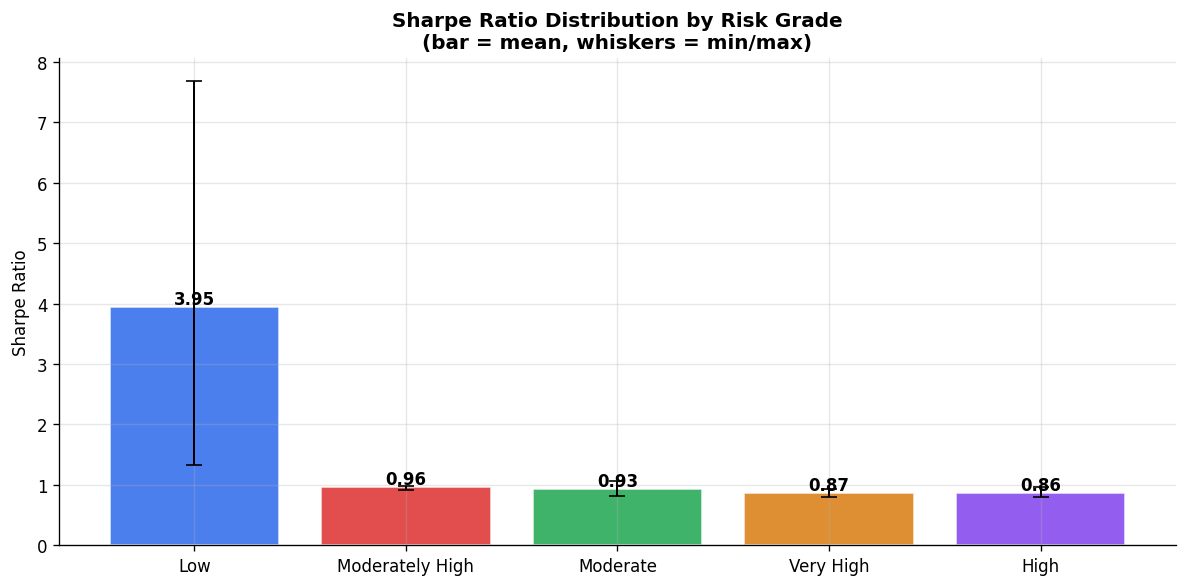


✅  Advanced_Analytics.ipynb — All 7 Tasks Complete!


In [13]:
# Insight 5: Sharpe comparison across risk tiers
sharpe_summary = (perf.groupby('risk_grade')['sharpe_ratio']
                  .agg(['mean','max','min','count'])
                  .round(3).sort_values('mean',ascending=False))
print("Sharpe Ratio by Risk Grade:")
print(sharpe_summary.to_string())

fig, ax = plt.subplots(figsize=(10,5))
cats = sharpe_summary.index.tolist()
ax.bar(cats, sharpe_summary['mean'], color=PALETTE[:len(cats)], alpha=0.82, edgecolor='white')
ax.errorbar(cats, sharpe_summary['mean'],
            yerr=[sharpe_summary['mean']-sharpe_summary['min'],
                  sharpe_summary['max']-sharpe_summary['mean']],
            fmt='none', color='black', capsize=5, linewidth=1.2)
ax.set_title('Sharpe Ratio Distribution by Risk Grade\n(bar = mean, whiskers = min/max)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
for bar, val in zip(ax.patches, sharpe_summary['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅  Advanced_Analytics.ipynb — All 7 Tasks Complete!")